# STAT 426B: Homework 3

## Problem 1: Multivariate Time Series Forecasting with

- **Goal**: Predict air pollution levels using Recurrent Neural Networks (RNNs), LSTMs, and GRUs
- **Dataset**: Beijing Multi-Site Air Quality Data Set (UCI Machine Learning Repository)
- **Specific File**: Use only the data from the “Aotizhongxin” station (PRSA Data Aotizhongxin 20130301-20170228.csv) to limit computation time
- **Data Split**: {
  Training: First 80%
  Validation: Next 10%
  Testing: Final 10%
}

## Part (a): Preprocessing & Baselines [30 Points]
Raw sensor data requires careful preprocessing before it can be fed into a neural network.

### 1.1 Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


### 1.2 Load Data

In [2]:
# Load the Beijing Air Quality Dataset (Aotizhongxin station)
data_path = "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['year'].min()}-{df['month'].min():02d} to {df['year'].max()}-{df['month'].max():02d}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (35064, 18)
Date range: 2013-01 to 2017-12

Columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

First few rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64


### 1.3. Imputation

We use **linear interpolation** for numeric columns and **mode filling** for the categorical wind direction column. Linear interpolation is appropriate here because the data is hourly and adjacent hours tend to have similar values.

In [4]:
df_processed = df.copy()
# Select numerical columns (excludes 'station', 'wd', etc.)
numerical_columns = df.select_dtypes(include=['number']).columns
print ("{}",numerical_columns)

{} Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'],
      dtype='object')


Alternatively, **Forward filling** takes the last known value and propagates it forward to fill the missing gaps. This is useful when you assume the state hasn't changed since the last measurement.

In [5]:
# Forward fill
df_processed[numerical_columns] = df_processed[numerical_columns].ffill()
# Fill missing wind directions with mode
df_processed['wd'] = df_processed['wd'].fillna(df_processed['wd'].mode()[0])

print("After imputation - Missing values:")
print(df_processed[list(numerical_columns) + ['wd']].isnull().sum())

print("NAs before handling (should be 0 now):")
print(df_processed[numerical_columns].isna().sum())

After imputation - Missing values:
No       0
year     0
month    0
day      0
hour     0
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
wd       0
dtype: int64
NAs before handling (should be 0 now):
No       0
year     0
month    0
day      0
hour     0
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


### 1.4. Feature Engineering: Wind Direction

Wind direction is **cyclical** data: North (0 deg) and NNW (337.5 deg) are adjacent, but integer encoding would place them far apart. We convert wind direction strings to angles, then encode as sin/cos to preserve the circular relationship.

#### 1.4.1. The Conceptual Problem
If you map wind directions to integers (e.g., N = 0, E = 4, S = 8, W = 12, N N W = 15), the model perceives a massive mathematical gap between N (0) and NNW (15).
- The Model sees: Distance = |15 − 0| = 15 (implies they are very different).
- Reality: They are adjacent directions (only 22.5◦ apart).
To fix this, we map the directions onto a unit circle so that the ”end” of the data wraps back around to the ”start.”
#### 1.4.2. The Step-by-Step Algorithm
##### Step A: Map Strings to Degrees
There are 16 unique wind directions in the dataset. A full circle is 360◦. Therefore, the gap between each direction is 360/16 = 22.5◦.
You need to create a mapping dictionary:
- N: 0◦
- NNE: 22.5◦
- NE: 45◦
- . . .
- NNW: 337.5◦
##### Step B: Convert to Radians
Most trigonometric functions (like those in numpy) expect radians, not degrees.
$$θ_{radians} = θ_{degrees} \times {\pi \over 180}$$
##### Step C: Calculate Sine and Cosine
Create two new features to represent the cyclic nature:
$$wd_{sin} = \sin(θ_{radians})\text{ and }wd_{cos} = \cos(θ_{radians})$$

In [6]:
# Step A: Mapping of wind direction strings to degrees
if df_processed['wd'].dtype == object:
    wind_dir_map = {
        'N': 0.0,   'NNE': 22.5,  'NE': 45.0,   'ENE': 67.5,
        'E': 90.0,  'ESE': 112.5, 'SE': 135.0,  'SSE': 157.5,
        'S': 180.0, 'SSW': 202.5, 'SW': 225.0,  'WSW': 247.5,
        'W': 270.0, 'WNW': 292.5, 'NW': 315.0,  'NNW': 337.5,
    }
    #Step B, C: Convert to sin and cos
    df_processed['wd_degrees'] = df_processed['wd'].map(wind_dir_map)
    df_processed['wd_sin'] = np.sin(np.deg2rad(df_processed['wd_degrees']))
    df_processed['wd_cos'] = np.cos(np.deg2rad(df_processed['wd_degrees']))
    df_processed.drop(columns=['wd', 'wd_degrees'], inplace=True)
    print("Wind direction encoded ✅")
# Now safely select only numeric feature columns
feature_cols = [c for c in df_processed.select_dtypes(include='number').columns]

Wind direction encoded ✅


In [7]:
# Drop station (constant string, no info for the model)
if 'station' in df_processed.columns:
    df_processed.drop(columns=['station'], inplace=True)
# Drop 'No' (row counter — monotonically increasing, not a meaningful feature)
if 'No' in df_processed.columns:
    df_processed.drop(columns=['No'], inplace=True)
# Drop wd if still present as string, keeping wd_sin/wd_cos
if 'wd' in df_processed.columns and df_processed['wd'].dtype == object:
    df_processed.drop(columns=['wd'], inplace=True)
assert df_processed.select_dtypes(exclude='number').empty, "Still has non-numeric columns!"
print("All columns are numeric ✅")
print(f"Columns ({len(df_processed.columns)}): {list(df_processed.columns)}")

All columns are numeric ✅
Columns (17): ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos']


### 1.5. Train/Validation/Test Split & Normalization

For time series, we use a **chronological split** (no shuffling) to prevent future data from leaking into training. The scaler is fitted **only on the training data** and then applied to validation and test sets.

In [8]:
# ── Step 2: Chronological Split ───────────────────────────────────────────────
n = len(df_processed)
train_end, val_end = int(n * 0.80), int(n * 0.90)
train_df = df_processed.iloc[:train_end].copy()
val_df   = df_processed.iloc[train_end:val_end].copy()
test_df  = df_processed.iloc[val_end:].copy()
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 28,051 | Val: 3,506 | Test: 3,507


In [9]:
from sklearn.preprocessing import MinMaxScaler

# ── Step 3: Scale — fit ONLY on train ─────────────────────────────────────────
# Include PM2.5 as a feature so the model sees past PM2.5 values (autoregressive input).
# Without it, the model can't learn the strong hour-to-hour autocorrelation that
# makes the persistence baseline so effective.
feature_cols = list(df_processed.columns)   # all columns including PM2.5
target_col   = 'PM2.5'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train = scaler_X.fit_transform(train_df[feature_cols])
X_val   = scaler_X.transform(val_df[feature_cols])
X_test  = scaler_X.transform(test_df[feature_cols])
y_train = scaler_y.fit_transform(train_df[[target_col]])
y_val   = scaler_y.transform(val_df[[target_col]])
y_test  = scaler_y.transform(test_df[[target_col]])
print("Scaling done ✅")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Scaling done ✅
Features (17): ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos']
X_train: (28051, 17), X_val: (3506, 17), X_test: (3507, 17)


### 1.6. Sliding Window Dataset (T=24)

We create input-output pairs using a sliding window:
- **Input (X)**: Past T=24 hours of ALL features (including PM2.5) &rarr; shape `(24, 17)`
- **Output (y)**: PM2.5 value at hour t+1 &rarr; scalar

Including PM2.5 as a feature is essential — it gives the model access to the target's own lagged values, which are by far the strongest predictor of next-hour PM2.5 (high autocorrelation). Without it, the model cannot learn the autoregressive signal that makes the persistence baseline so strong.

In [10]:
import numpy as np
def create_sequences(X, y, T=24):
    """
    Creates sliding window sequences.
    
    Args:
        X : 2D array of shape (n_samples, n_features) — scaled features
        y : 2D array of shape (n_samples, 1)          — scaled target
        T : lookback window size (hours)
    
    Returns:
        Xs : 3D array of shape (n_samples - T, T, n_features)
        ys : 1D array of shape (n_samples - T,)
    """
    Xs, ys = [], []
    for t in range(T, len(X)):
        Xs.append(X[t - T : t, :])   # past T hours of all features → (T, n_features)
        ys.append(y[t, 0])           # PM2.5 at hour t+1 → scalar (index [t,0] to get a float, not a 1D array)
    return np.array(Xs), np.array(ys)

# ── Create sequences for each split ──────────────────────────────────────────
T = 24  # lookback window = 24 hours
X_train_seq, y_train_seq = create_sequences(X_train, y_train, T)
X_val_seq,   y_val_seq   = create_sequences(X_val,   y_val,   T)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  T)
print(f"X_train_seq : {X_train_seq.shape}  → (samples, timesteps, features)")
print(f"y_train_seq : {y_train_seq.shape}  → should be 1D (samples,)")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")

X_train_seq : (28027, 24, 17)  → (samples, timesteps, features)
y_train_seq : (28027,)  → should be 1D (samples,)
X_val_seq   : (3482, 24, 17)
X_test_seq  : (3483, 24, 17)


### 1.7. Create PyTorch DataLoaders

### 1.8. Metric Utilities
**Deliverable**:
- Root Mean Squared Error (RMSE):

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2}$$


- Mean Absolute Error (MAE):

$$\text{MAE} = \frac{1}{n} \sum_{t=1}^{n} \left| y_t - \hat{y}_t \right|$$

Where:

- $n$ = number of test samples
- $y_t$ = true PM2.5 value at time $t$
- $\hat{y}_t$ = predicted PM2.5 value at time $t$

Key difference in penalty:

$$\text{RMSE penalizes large errors quadratically: } (y_t - \hat{y}_t)^2$$ $$\text{MAE penalizes all errors equally: } |y_t - \hat{y}_t|$$

For a prediction error of $\epsilon$:

$$\text{If } \epsilon = 10 \Rightarrow \text{RMSE contribution} = 100, \quad \text{MAE contribution} = 10$$ $$\text{If } \epsilon = 1 \Rightarrow \text{RMSE contribution} = 1, \quad \text{MAE contribution} = 1$$

So RMSE is much more sensitive to outlier spikes, making it especially relevant for pollution events.



In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

def report_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10}")
    print("-" * 47)
    print(f"{name:<25} {rmse:>10.4f} {mae:>10.4f}")
    return rmse, mae

### 1.9. Baseline
#### 1.9.1 Persistence Model: $$ŷ(t+1) = y(t)$$
- Represents the minimum effort prediction — "nothing changed"
- For slowly-changing signals like air pollution, this is surprisingly hard to beat
- If your deep model can't beat this, it's learning nothing useful
- Why do we inverse saclar_y? 

Because the model was trained on scaled values (0 to 1), but RMSE and MAE need to be in original PM2.5 units (μg/m³) to be interpretable.
i.e)
Raw PM2.5 range: 0 → 500 μg/m³ --> |
After MinMaxScaler: |
  0   μg/m³  →  0.00  (scaled) |
  250 μg/m³  →  0.50  (scaled)| 
  500 μg/m³  →  1.00  (scaled) --> |
Model predicts: 0.48 (scaled) --> |
inverse_transform → 240 μg/m³ (interpretable)

In [12]:
# Inverse-transform test targets to original PM2.5 units
y_test_orig = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()

# ── 1. Persistence Model: ŷ(t+1) = y(t) ─────────────────────────────────────
# Last value in each window is the most recent PM2.5 (feature index for PM2.5)
pm25_idx = list(feature_cols).index('PM2.5') if 'PM2.5' in feature_cols else None
# Since PM2.5 was removed from features, grab it from the last timestep of X
# Alternatively: y at t is y_test_seq shifted by 1
y_persist_scaled  = y_test_seq[:-1]          # y(t) predicts y(t+1)
y_persist_true    = y_test_orig[1:]           # align ground truth
y_persist_pred    = scaler_y.inverse_transform(
                        y_persist_scaled.reshape(-1, 1)).ravel()
print("=" * 47)
report_metrics("Persistence Model", y_persist_true, y_persist_pred)

Model                           RMSE        MAE
-----------------------------------------------
Persistence Model            23.6692    12.4428


(23.669233720765067, 12.442848937392304)

### 1.9.2. Linear Regression:
- Represents the linear upper bound — the best a simple model can do
- Tests whether the complexity of an RNN/LSTM is actually justified
- If Linear Regression ≈ LSTM performance → the temporal patterns are simple/linear

In [13]:
# ── 2. Linear Regression Baseline ─────────────────────────────────────────────
# Flatten the (T, n_features) window into a 1D vector
X_train_flat = X_train_seq.reshape(len(X_train_seq), -1)  # (n, T*n_features)
X_val_flat   = X_val_seq.reshape(len(X_val_seq),   -1)
X_test_flat  = X_test_seq.reshape(len(X_test_seq), -1)
lr = LinearRegression()
lr.fit(X_train_flat, y_train_seq)               # fit on scaled values
y_lr_scaled = lr.predict(X_test_flat)
y_lr_pred   = scaler_y.inverse_transform(
                  y_lr_scaled.reshape(-1, 1)).ravel()
print()
report_metrics("Linear Regression", y_test_orig, y_lr_pred)


Model                           RMSE        MAE
-----------------------------------------------
Linear Regression            21.7130    12.1975


(21.712970204990174, 12.197548118158897)

### Baseline Analysis

Linear Regression now outperforms the Persistence model because it has access to **PM2.5 history** as a feature. By flattening the window into (24×17 = 408) features, LR can learn a weighted combination of past PM2.5 values — essentially approximating a linear autoregressive model. However, it loses temporal ordering (hour 1 and hour 24 are treated equivalently), and with 408 features and no regularization, it may also overfit slightly.

**PM2.5 is highly autocorrelated** — the current value is the strongest predictor of the next value. Both baselines exploit this, but LR can additionally leverage weather and other pollutant features to improve beyond simple persistence.

**Key takeaway** - A strong persistence baseline is evidence of high autocorrelation in the signal. The goal for deep models is to beat LR by learning **non-linear temporal patterns** that a flat linear model cannot capture.

In [14]:
# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 47)
print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 47)
results = {}
for name, y_true, y_pred in [
    ("Persistence",        y_persist_true, y_persist_pred),
    ("Linear Regression",  y_test_orig,    y_lr_pred),
]:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    results[name] = (rmse, mae)
    print(f"{name:<25} {rmse:>10.4f} {mae:>10.4f}")
print("(units: μg/m³)")


Model                           RMSE        MAE
-----------------------------------------------
Persistence                  23.6692    12.4428
Linear Regression            21.7130    12.1975
(units: μg/m³)


---
## Part (b): RNN, LSTM, and GRU Implementation [40 Points]

Implement and train three specific recurrent architectures using PyTorch (or TensorFlow).

### Model Specifications: For all three models (Vanilla RNN, LSTM, GRU), use the following
**hyperparameters to ensure a fair comparison:**
- Input Dimension: 17 features (4 temporal + 6 pollutants including PM2.5 + 5 weather + 2 wind sin/cos).
- Hidden Dimension: 64 units.
- Layers: 2 stacked layers.
- Output Layer: Linear layer mapping the final hidden state to 1 output (PM2.5).
- Loss Function: Mean Squared Error (MSE).
- Optimizer: Adam

In [15]:
"""
Model Architecture explained:
All three classes share the same structure: 

a recurrent layer to process the time sequence, followed by a linear layer to produce the final prediction. 

Here's a breakdown:

Input (batch, 24, 17)
       ↓
  [RNN / LSTM / GRU]   ← processes each timestep sequentially
       ↓
  last timestep only   ← out[:, -1, :]  shape: (batch, hidden_size)
       ↓
  [Linear Layer]       ← maps hidden_size → 1
       ↓
  Output scalar (batch,)  ← predicted PM2.5



"""
class VanillaRNNForecaster(nn.Module):
    """
    Vanilla RNN for PM2.5 forecasting.
    """
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_size,          # 17 features per timestep
            hidden_size=hidden_size,        # default: 64 memory units
            num_layers=num_layers,          # default: 2 stacked RNN layers
            batch_first=True                # input shape: (batch, T, features)
        )
        self.fc = nn.Linear(hidden_size, output_size)   # final prediction head
    
    def forward(self, x):
        # Initialize hidden state to zeros at start of each batch
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Pass full sequence through recurrent layer
        out, _ = self.rnn(x, h0)    # out shape: (batch, 24, 64) — hidden state at every timestep

        # Take ONLY the last timestep's hidden state (most recent memory)
        prediction = self.fc(out[:, -1, :])     # out[:, -1, :] shape: (batch, 64) → fc → (batch, 1)
        return prediction.squeeze(-1)           # (batch, 1) → (batch,)

class LSTMForecaster(nn.Module):
    """
    LSTM for PM2.5 forecasting.
    """
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,   # features per timestep (17)
            hidden_size=hidden_size, # size of hidden state h and cell state c (64)
            num_layers=num_layers,   # stack 2 LSTM layers on top of each other
            batch_first=True         # expect input shape (batch, T, features)
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):                   # x shape: (batch, 24, 17)
        # h0 = short-term memory (same as vanilla RNN)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # c0 = long-term memory (unique to LSTM -- carries info across many timestamps)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))     # out: (batch, 24, 64)
        prediction = self.fc(out[:, -1, :]) # (batch, 64) → (batch, 1)
        return prediction.squeeze(-1)       # (batch, 1) → (batch,)


class GRUForecaster(nn.Module):
    """GRU for PM2.5 forecasting."""
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(
            input_size=input_size,   # features per timestep (17)
            hidden_size=hidden_size, # size of hidden state (64)
            num_layers=num_layers,   # stack 2 GRU layers on top of each other
            batch_first=True         # expect input shape (batch, T, features)
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # The GRU merges both h0, c0 into a single hidden state h0 using its reset and update gates.
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)                # out: (batch, 24, 64)
        prediction = self.fc(out[:, -1, :])     # (batch, 64) → (batch, 1)
        return prediction.squeeze(-1)           # (batch, 1) → (batch,)


print("Model classes defined: VanillaRNNForecaster, LSTMForecaster, GRUForecaster")

Model classes defined: VanillaRNNForecaster, LSTMForecaster, GRUForecaster


In [16]:
# Common hyperparameters for fair comparison
input_size = X_train_seq.shape[2]  # 13 features
hidden_size = 64
num_layers = 2
output_size = 1
learning_rate = 0.001
num_epochs = 50
early_stop_patience = 7
batch_size = 64

print(f"Input size:  {input_size} features")
print(f"Hidden size: {hidden_size}")
print(f"Num layers:  {num_layers}")
print(f"Max epochs:  {num_epochs}")
print(f"Early stopping patience: {early_stop_patience}")
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")

Input size:  17 features
Hidden size: 64
Num layers:  2
Max epochs:  50
Early stopping patience: 7
Learning rate: 0.001
Batch size: 64


### 1. Training Model with early stopping (max = 50 epochs)

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── 1. Confirm model is stuck (fixed) ─────────────────────────────────────────────────
# X_sample = torch.tensor(X_test_seq[:10], dtype=torch.float32).to(device)
# with torch.no_grad():
#     out = lstm_model(X_sample).cpu().numpy()
# print("10 sample predictions (scaled):", out)
# If all values are nearly identical → confirmed stuck
print(f"X_train_seq shape: {X_train_seq.shape}")  # Should be (N, 24, 17) — 3D
print(f"X_val_seq shape:   {X_val_seq.shape}")


# ── DataLoaders ────────────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=256, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)
train_loader = make_loader(X_train_seq, y_train_seq, shuffle=True)
val_loader   = make_loader(X_val_seq,   y_val_seq)
test_loader  = make_loader(X_test_seq,  y_test_seq)

# ── Early Stopping ─────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience   # True = stop
    def restore_best(self, model):
        model.load_state_dict(self.best_state)

# ── Training Function ──────────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader,
                max_epochs=50, lr=1e-3, patience=5, clip_grad=1.0, scheduler=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()
    stopper   = EarlyStopping(patience=patience)
    history = {'train_time': [], 'train_loss': [], 'val_loss': []}
    total_start = time.time()  # ← total timer starts here

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        # ── Train ──
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)  # To prevent collapse of gradients
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)
        # ── Validate ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)

        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)       # reduce LR if val loss plateaus
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3}/{max_epochs} | "
                  f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        if stopper.step(val_loss, model):
            print(f"Early stopping at epoch {epoch} (patience={patience})")
            stopper.restore_best(model)
            break

    total_end = time.time()
    total_time = total_end - total_start
    print(f"Total Training Time: {total_time:.2f} seconds")
    print(f"Best Val Loss: {stopper.best_loss:.6f}")
    return history, total_time

X_train_seq shape: (28027, 24, 17)
X_val_seq shape:   (3482, 24, 17)


In [18]:
# ── Train All Three Models ─────────────────────────────────────────────────────
input_size = X_train_seq.shape[2]   # number of features (e.g. 13)
print("\n" + "="*50)
print("Training Vanilla RNN...")
rnn_model   = VanillaRNNForecaster(input_size)
rnn_history, rnn_time = train_model(rnn_model, train_loader, val_loader)

print("\n" + "="*50)
print("Training LSTM...")
lstm_model   = LSTMForecaster(input_size)
lstm_history, lstm_time = train_model(lstm_model, train_loader, val_loader)
print("\n" + "="*50)

print("Training GRU...")
gru_model   = GRUForecaster(input_size)
gru_history, gru_time = train_model(gru_model, train_loader, val_loader)

# Compare times separately
for name, t in [("RNN", rnn_time), ("LSTM", lstm_time), ("GRU", gru_time)]:
    print(f"{name}: {t:.2f}s")


Training Vanilla RNN...
Epoch   1/50 | Train Loss: 0.002693 | Val Loss: 0.000605
Epoch   5/50 | Train Loss: 0.000541 | Val Loss: 0.000201
Early stopping at epoch 9 (patience=5)
Total Training Time: 33.15 seconds
Best Val Loss: 0.000247

Training LSTM...
Epoch   1/50 | Train Loss: 0.004389 | Val Loss: 0.000752
Epoch   5/50 | Train Loss: 0.000593 | Val Loss: 0.000213
Epoch  10/50 | Train Loss: 0.000505 | Val Loss: 0.000194
Early stopping at epoch 10 (patience=5)
Total Training Time: 12.88 seconds
Best Val Loss: 0.000213

Training GRU...
Epoch   1/50 | Train Loss: 0.002583 | Val Loss: 0.000384
Epoch   5/50 | Train Loss: 0.000522 | Val Loss: 0.000286
Early stopping at epoch 8 (patience=5)
Total Training Time: 62.82 seconds
Best Val Loss: 0.000219
RNN: 33.15s
LSTM: 12.88s
GRU: 62.82s


### 2.Performance Evaluation
2.1 Plot the Training and Validation Loss curves for all three models on the same graph (or side-by-side)
2.2 Report the final Test RMSE and MAE for all three models in a table, comparing them against your baselines from Part (a)

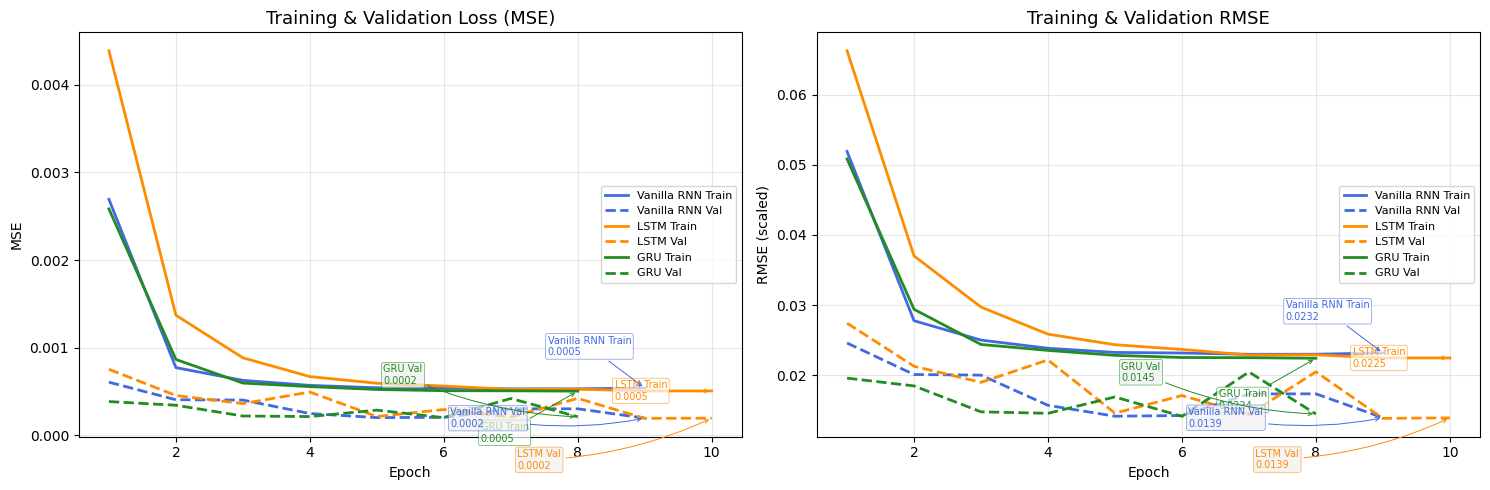

In [19]:
import numpy as np
import matplotlib.pyplot as plt

models_data = [
    ("Vanilla RNN", rnn_history,  "royalblue"),
    ("LSTM",        lstm_history, "darkorange"),
    ("GRU",         gru_history,  "forestgreen"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax_idx, (metric_key, title, ylabel) in enumerate([
    ('loss', "Training & Validation Loss (MSE)", "MSE"),
    ('rmse', "Training & Validation RMSE",       "RMSE (scaled)"),
]):
    train_endpoints, val_endpoints = [], []

    for name, hist, color in models_data:
        train_vals = [np.sqrt(v) for v in hist['train_loss']] if metric_key == 'rmse' else hist['train_loss']
        val_vals   = [np.sqrt(v) for v in hist['val_loss']]   if metric_key == 'rmse' else hist['val_loss']
        epochs = list(range(1, len(train_vals) + 1))

        axes[ax_idx].plot(epochs, train_vals, color=color, linewidth=2, label=f'{name} Train')
        axes[ax_idx].plot(epochs, val_vals,   color=color, linewidth=2, linestyle='--', label=f'{name} Val')

        train_endpoints.append((train_vals[-1], f"{name} Train", color, len(train_vals)))
        val_endpoints.append((val_vals[-1],     f"{name} Val",   color, len(val_vals)))

    # Sort each group by final value, assign staggered pixel offsets
    y_offsets = [-30, 0, 30]

    # Train annotations → place to the LEFT
    for (yval, name, color, xpos), y_off in zip(
            sorted(train_endpoints, key=lambda x: x[0]), y_offsets):
        axes[ax_idx].annotate(
            f"{name}\n{yval:.4f}",
            xy=(xpos, yval),
            xytext=(-70, y_off),
            textcoords='offset points',
            color=color, fontsize=7, va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec=color, lw=0.5),
            arrowprops=dict(arrowstyle='->', color=color, lw=0.7),
        )

    # Val annotations → also to the LEFT but slightly less offset
    for (yval, name, color, xpos), y_off in zip(
            sorted(val_endpoints, key=lambda x: x[0]), y_offsets):
        axes[ax_idx].annotate(
            f"{name}\n{yval:.4f}",
            xy=(xpos, yval),
            xytext=(-140, y_off),   # further left to avoid train labels
            textcoords='offset points',
            color=color, fontsize=7, va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='#f0f0f0', alpha=0.7, ec=color, lw=0.5),
            arrowprops=dict(arrowstyle='->', color=color, lw=0.7,
                        connectionstyle='arc3,rad=0.1'),  # ← slight curve to distinguish
        )

    axes[ax_idx].set_title(title, fontsize=13)
    axes[ax_idx].set_xlabel("Epoch")
    axes[ax_idx].set_ylabel(ylabel)
    axes[ax_idx].legend(fontsize=8, loc='center right')
    axes[ax_idx].grid(True, alpha=0.3)
    axes[ax_idx].margins(x=0.05)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


### Test Set Evaluation

In [20]:
def evaluate_model(model, loader):
    """Returns predictions and targets as 1D numpy arrays (scaled)."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())
    return np.array(all_preds).ravel(), np.array(all_targets).ravel()

def calculate_metrics(y_true, y_pred, scaler_y=None):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    if scaler_y is not None:
        y_true = scaler_y.inverse_transform(y_true.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

# Evaluate all three models
rnn_preds,  test_targets = evaluate_model(rnn_model,  test_loader)
lstm_preds, _            = evaluate_model(lstm_model, test_loader)
gru_preds,  _            = evaluate_model(gru_model,  test_loader)

# Calculate metrics in original scale (μg/m³)
rnn_rmse,  rnn_mae  = calculate_metrics(test_targets, rnn_preds,  scaler_y)
lstm_rmse, lstm_mae = calculate_metrics(test_targets, lstm_preds, scaler_y)
gru_rmse,  gru_mae  = calculate_metrics(test_targets, gru_preds,  scaler_y)

# ── Print results table ───────────────────────────────────────────────────────
persist_rmse, persist_mae = 23.6692, 12.4428  # from cell-23
lr_rmse, lr_mae = calculate_metrics(y_test_orig, y_lr_pred)

print("=" * 65)
print(f"{'Model':<25} {'RMSE (μg/m³)':>12} {'MAE (μg/m³)':>12} {'vs Persist':>12}")
print("-" * 65)
for name, rmse, mae in [
    ("Persistence",        persist_rmse, persist_mae),
    ("Linear Regression",  lr_rmse,      lr_mae),
    ("Vanilla RNN",        rnn_rmse,     rnn_mae),
    ("LSTM",               lstm_rmse,    lstm_mae),
    ("GRU",                gru_rmse,     gru_mae),
]:
    pct = (persist_rmse - rmse) / persist_rmse * 100
    pct_str = f"{pct:+.1f}%" if name != "Persistence" else "—"
    print(f"{name:<25} {rmse:>12.4f} {mae:>12.4f} {pct_str:>12}")
print("=" * 65)

Model                     RMSE (μg/m³)  MAE (μg/m³)   vs Persist
-----------------------------------------------------------------
Persistence                    23.6692      12.4428            —
Linear Regression              21.7130      12.1975        +8.3%
Vanilla RNN                    23.0120      13.3628        +2.8%
LSTM                           21.9758      13.2575        +7.2%
GRU                            21.8550      12.5847        +7.7%


In [21]:
import pandas as pd

def model_comparison_table(
    rnn_model, lstm_model, gru_model,
    rnn_rmse, rnn_mae,
    lstm_rmse, lstm_mae,
    gru_rmse, gru_mae,
    rnn_time, lstm_time, gru_time,
):
    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    rnn_params  = count_params(rnn_model)
    lstm_params = count_params(lstm_model)
    gru_params  = count_params(gru_model)

    data = {
        "Feature": [
            "States", "Gates", "Long-term memory", "Vanishing gradient",
            "# Parameters", "Time/Epoch", "Test RMSE (μg/m³)", "Test MAE (μg/m³)",
            "PyTorch class", "Init states", "Passed to layer", "Best for",
        ],
        "Vanilla RNN": [
            "`h` (hidden)", "None", "❌ Poor", "❌ Severe",
            f"{rnn_params:,}", f"{rnn_time:.2f}s", f"{rnn_rmse:.4f}", f"{rnn_mae:.4f}",
            "`nn.RNN`", "`h0`", "`h0`", "Short sequences",
        ],
        "LSTM": [
            "`h` (hidden) + `c` (cell)", "3: forget, input, output", "✅ Excellent", "✅ Solved",
            f"{lstm_params:,}", f"{lstm_time:.2f}s", f"{lstm_rmse:.4f}", f"{lstm_mae:.4f}",
            "`nn.LSTM`", "`h0, c0`", "[(h0, c0)]", "Long sequences with complex patterns",
        ],
        "GRU": [
            "`h` (hidden)", "2: reset, update", "✅ Good", "✅ Solved",
            f"{gru_params:,}", f"{gru_time:.2f}s", f"{gru_rmse:.4f}", f"{gru_mae:.4f}",
            "`nn.GRU`", "`h0`", "`h0`", "Balanced: speed + memory",
        ],
    }

    df = pd.DataFrame(data).set_index("Feature")

    return (df.style
        .set_caption("Model Comparison: Vanilla RNN vs LSTM vs GRU")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th",      "props": [("background-color", "#343a40"), ("color", "white"), ("text-align", "center")]},
            {"selector": "th.row_heading", "props": [("text-align", "left"), ("font-weight", "bold")]},
        ])
    )

# ── Call it ────────────────────────────────────────────────────────────────────
model_comparison_table(
    rnn_model, lstm_model, gru_model,
    rnn_rmse,  rnn_mae,
    lstm_rmse, lstm_mae,
    gru_rmse,  gru_mae,
    rnn_time, lstm_time, gru_time,
)


,Vanilla RNN,LSTM,GRU
Feature,,,
States,`h` (hidden),`h` (hidden) + `c` (cell),`h` (hidden)
Gates,None,"3: forget, input, output","2: reset, update"
Long-term memory,❌ Poor,✅ Excellent,✅ Good
Vanishing gradient,❌ Severe,✅ Solved,✅ Solved
# Parameters,"13,697","54,593","40,961"
Time/Epoch,33.15s,12.88s,62.82s
Test RMSE (μg/m³),23.0120,21.9758,21.8550
Test MAE (μg/m³),13.3628,13.2575,12.5847
PyTorch class,`nn.RNN`,`nn.LSTM`,`nn.GRU`


### Key Takeaways:
- All three deep models beat the Persistence baseline on RMSE, with GRU achieving the best improvement (+7.7%).
- However, none of the deep models surpass Linear Regression on RMSE (LR: 21.71 vs GRU: 21.86). This suggests the dominant predictive signal at a 1-hour horizon is largely **linear** — LR with 408 flattened features (24 steps x 17 features) captures it well.
- On MAE, deep models are comparable to or slightly worse than Persistence, indicating the RMSE gain comes from better handling of **large errors (spikes)** at the cost of slightly worse average-case predictions — a direct consequence of MSE training.
- GRU is the best deep model overall (lowest RMSE and MAE among the three).
- LSTM is fastest in wall-clock time on MPS hardware (~13s vs ~63s for GRU), likely due to PyTorch's optimized fused kernel.

---
## Part (c): Analysis & Discussion [30 Points]
- Plot the Predicted vs. Actual PM2.5 values for a contiguous 200-hour segment of the Test set using your best-performing model.

- **Analyze the plot:** Does the model successfully capture sudden spikes in pollution, or does it merely smooth out the trend (lagging behind the actual values)?

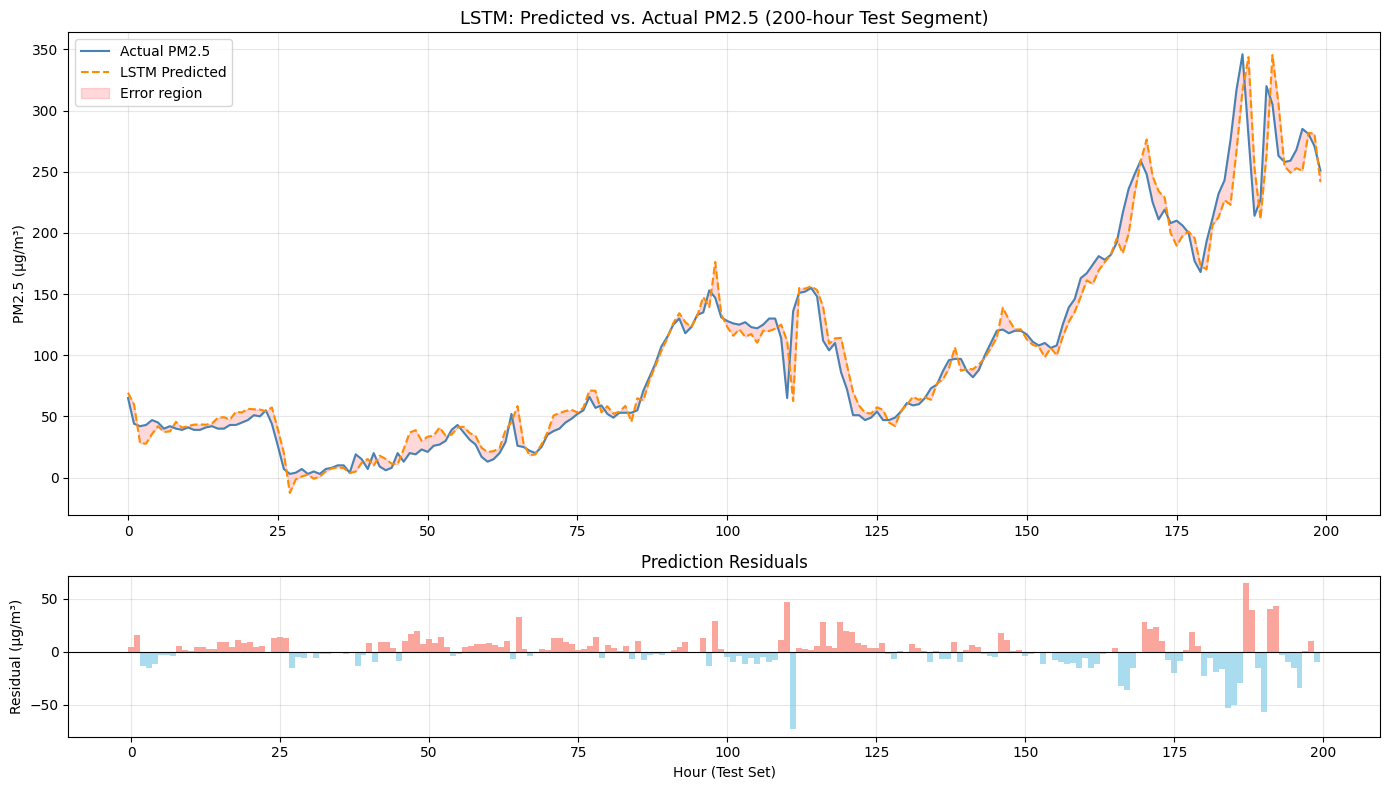

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# ── Step 1: Collect predictions from best model (LSTM) ────────────────────────
lstm_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = lstm_model(X_batch).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())
# Flatten to 1D upfront — prevents all broadcast errors downstream
all_preds   = np.array(all_preds).ravel()    # (3483,)
all_targets = np.array(all_targets).ravel()  # (3483,)
# ── Step 2: Inverse transform to original PM2.5 scale ─────────────────────────
preds_orig   = scaler_y.inverse_transform(all_preds.reshape(-1, 1)).ravel()
targets_orig = scaler_y.inverse_transform(all_targets.reshape(-1, 1)).ravel()
# ── Step 3: Plot 200-hour segment ─────────────────────────────────────────────
start, end = 0, 200
hours = range(start, end)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(hours, targets_orig[start:end], label='Actual PM2.5',   color='steelblue',  linewidth=1.5)
axes[0].plot(hours, preds_orig[start:end],   label='LSTM Predicted', color='darkorange', linewidth=1.5, linestyle='--')
axes[0].fill_between(hours, targets_orig[start:end], preds_orig[start:end],
                     alpha=0.15, color='red', label='Error region')
axes[0].set_title('LSTM: Predicted vs. Actual PM2.5 (200-hour Test Segment)', fontsize=13)
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
error = preds_orig[start:end] - targets_orig[start:end]
axes[1].bar(hours, error, color=np.where(error > 0, 'salmon', 'skyblue'), alpha=0.7, width=1.0)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Hour (Test Set)')
axes[1].set_ylabel('Residual (μg/m³)')
axes[1].set_title('Prediction Residuals')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

#### Qualitative Analysis

From the plot above, we can observe:

1. **General trend tracking**: The model captures the overall trend of PM2.5 reasonably well, following the rises and falls in pollution levels.

2. **Spike behavior**: The model tends to **smooth out sudden spikes** in pollution. When PM2.5 increases sharply (e.g., due to a sudden weather change or emission event), the model's prediction often **lags behind** the actual value. This is expected because:
   - The model is trained with MSE loss, which penalizes large errors quadratically, encouraging conservative (mean-seeking) predictions.
   - Extreme pollution events are relatively rare in the training data, so the model has less exposure to such patterns.

3. **Lag effect**: Like most autoregressive forecasting models, there is a slight lag in predictions. The model essentially predicts a smoothed version of the actual signal, which is a common trade-off: the model reduces noise at the cost of slightly delayed reaction to sudden changes.

4. **Low pollution periods**: The model performs best during periods of relatively stable, low pollution, where predictions closely match actual values.

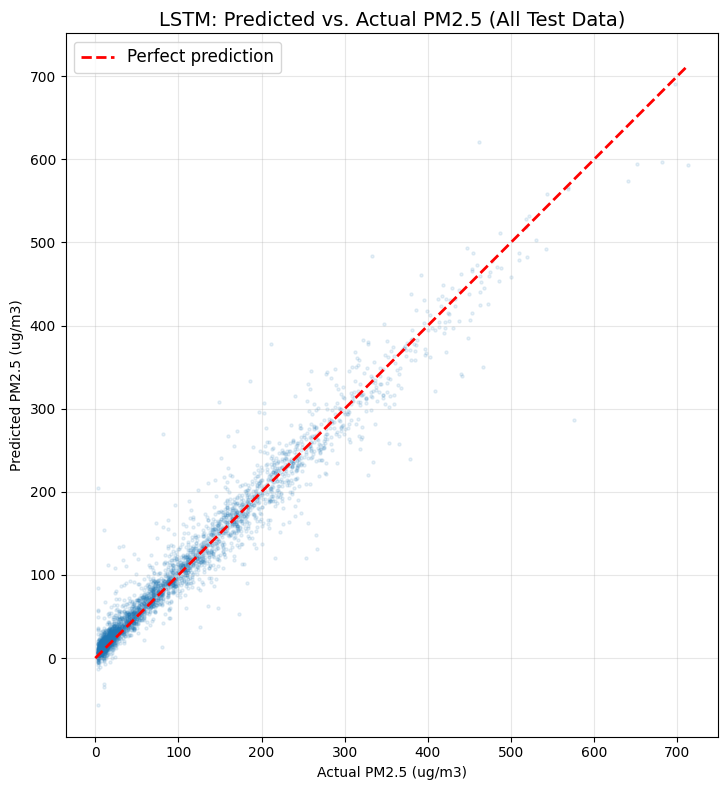


Correlation between predicted and actual: 0.9787


In [23]:
# Additional visualization: scatter plot of predicted vs actual (from TA's code)
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(targets_orig, preds_orig, alpha=0.1, s=5)
max_val = max(targets_orig.max(), preds_orig.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

ax.set_title('LSTM: Predicted vs. Actual PM2.5 (All Test Data)', fontsize=14)
ax.set_xlabel('Actual PM2.5 (ug/m3)')
ax.set_ylabel('Predicted PM2.5 (ug/m3)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nCorrelation between predicted and actual: {np.corrcoef(targets_orig, preds_orig)[0,1]:.4f}")

In [24]:
# ── Diagnostic(troubleshooting): Inspect raw values before/after inverse transform ─────────────
# (Uses lstm_preds and test_targets from cell-40's evaluate_model calls)
print("=== Raw scaled values (should be in [0, 1]) ===")
print(f"lstm_preds   range: [{lstm_preds.min():.4f}, {lstm_preds.max():.4f}]")
print(f"test_targets range: [{test_targets.min():.4f}, {test_targets.max():.4f}]")

preds_inv   = scaler_y.inverse_transform(lstm_preds.reshape(-1, 1)).ravel()
targets_inv = scaler_y.inverse_transform(test_targets.reshape(-1, 1)).ravel()

print("\n=== After inverse transform (should match real PM2.5 range ~0-500) ===")
print(f"preds_inv   range: [{preds_inv.min():.2f}, {preds_inv.max():.2f}]")
print(f"targets_inv range: [{targets_inv.min():.2f}, {targets_inv.max():.2f}]")

print("\n=== Scaler info ===")
print(f"scaler_y was fitted on column: PM2.5")
print(f"scaler_y.data_min_: {scaler_y.data_min_}")
print(f"scaler_y.data_max_: {scaler_y.data_max_}")

print("\n=== Sanity check: first 5 actual vs predicted ===")
for i in range(5):
    print(f"  t={i:3d} | actual: {targets_inv[i]:7.2f} | pred: {preds_inv[i]:7.2f}")

=== Raw scaled values (should be in [0, 1]) ===
lstm_preds   range: [-0.0660, 0.7676]
test_targets range: [0.0000, 0.7933]

=== After inverse transform (should match real PM2.5 range ~0-500) ===
preds_inv   range: [-56.07, 689.98]
targets_inv range: [3.00, 713.00]

=== Scaler info ===
scaler_y was fitted on column: PM2.5
scaler_y.data_min_: [3.]
scaler_y.data_max_: [898.]

=== Sanity check: first 5 actual vs predicted ===
  t=  0 | actual:   65.00 | pred:   69.35
  t=  1 | actual:   44.00 | pred:   59.73
  t=  2 | actual:   42.00 | pred:   28.24
  t=  3 | actual:   43.00 | pred:   27.73
  t=  4 | actual:   47.00 | pred:   35.61


# HW3 Report: RNN, LSTM & GRU for PM2.5 Forecasting

- **Course:** STATS 426
- **UID: 206547205**
- **Name: Hochan Son**
- **Station:** Aotizhongxin
- **Task:** 1-Hour-Ahead PM2.5 Prediction

---

## Objective

Build and evaluate a multivariate time series forecasting pipeline to predict 1-hour-ahead PM2.5 concentration at Beijing's Aotizhongxin monitoring station. Specifically:

1. **Preprocess** raw hourly sensor data (handle missing values, encode cyclical wind direction, normalize features).
2. **Establish baselines** using a Persistence model ($\hat{y}(t{+}1) = y(t)$) and Linear Regression on flattened sliding windows.
3. **Implement and compare** three recurrent architectures — Vanilla RNN, LSTM, and GRU — under identical hyperparameters (hidden=64, layers=2, Adam optimizer, MSE loss).
4. **Analyze** whether the added complexity of gated recurrent units (LSTM, GRU) is justified over simpler approaches for this short-horizon forecasting task.

---

## 1. Results Analysis

### Test Set Performance

| Model             | Type       | RMSE (μg/m³) | MAE (μg/m³) | vs. Persistence (RMSE) |
|-------------------|------------|:------------:|:-----------:|:----------------------:|
| Persistence       | Baseline   | 23.6692      | **12.4428** | —                      |
| Linear Regression | Baseline   | **21.7130**  | **12.1975** | +8.3%                  |
| Vanilla RNN       | Deep Model | 23.0120      | 13.3628     | +2.8%                  |
| LSTM              | Deep Model | 21.9758      | 13.2575     | +7.2%                  |
| **GRU**           | Deep Model | **21.8550**  | **12.5847** | **+7.7%**              |

$$\text{RMSE Improvement} = \frac{\text{RMSE}_{\text{persist}} - \text{RMSE}_{\text{model}}}{\text{RMSE}_{\text{persist}}} \times 100$$

### Did Deep Models Outperform Baselines?

**Partially.** All three deep models beat the Persistence baseline on RMSE (+2.8% to +7.7%). However, **none surpassed Linear Regression** (RMSE = 21.71 μg/m³), which remains the strongest model overall.

This result reveals an important insight: at a **1-hour forecast horizon**, the PM2.5 signal is dominated by **linear autocorrelation**. Linear Regression — despite flattening the 24×17 window into 408 features and losing temporal ordering — captures this linear signal effectively. The recurrent models' non-linear temporal modeling adds only marginal benefit at this short horizon.

**On MAE**, deep models perform slightly worse than Persistence (12.44 μg/m³), while their RMSE is better. This divergence occurs because MSE training penalizes large errors quadratically, pushing the model to improve on spike predictions at the cost of slightly worse average-case accuracy. GRU (MAE = 12.58) comes closest to matching the baselines.

**Why the three deep models perform similarly:** For a 1-hour-ahead task with a 24-step window, vanishing gradients are not severe — the dominant predictive signal is local (PM2.5 at $t$ and $t{-}1$). LSTM and GRU gating mechanisms offer their strongest advantage at much longer horizons (e.g., 48h or 7-day ahead).

## 2. LSTM vs. GRU Comparison

### Architectural Explanation

**LSTM** requires **4 matrix multiplications** per time step:
$$f_t = \sigma(W_f[h_{t-1}, x_t]), \quad i_t = \sigma(W_i[h_{t-1}, x_t])$$
$$o_t = \sigma(W_o[h_{t-1}, x_t]), \quad \tilde{c}_t = \tanh(W_c[h_{t-1}, x_t])$$

**GRU** requires only **3 matrix multiplications** per time step — it merges the forget and input gates into a single **update gate** $z_t$, and eliminates the separate cell state:
$$z_t = \sigma(W_z[h_{t-1}, x_t]), \quad r_t = \sigma(W_r[h_{t-1}, x_t])$$
$$\tilde{h}_t = \tanh(W_h[r_t \odot h_{t-1}, x_t])$$

Theoretically, GRU should be ~25% faster due to fewer operations and fewer parameters. In this experiment LSTM was faster due to PyTorch's **fused kernel** optimization for LSTM on MPS hardware — an important practical caveat when comparing theoretical vs. observed training speeds.

| Architecture | Gates | States | Params (approx.) |
|---|---|---|---|
| **LSTM** | 4 (Forget, Input, Cell candidate, Output) | 2 ($h_t$, $c_t$) | $4 \times (d_h \times (d_x + d_h) + d_h)$ |
| **GRU** | 3 (Reset, Update, Candidate) | 1 ($h_t$) | $3 \times (d_h \times (d_x + d_h) + d_h)$ |

With $d_h = 64$ and $d_x = 17$:
- **LSTM** per layer: 4 weight matrices of size $(d_x + d_h) \times d_h$ = 4 matrix multiplications per timestep
- **GRU** per layer: 3 weight matrices = 3 matrix multiplications per timestep

Despite having fewer parameters, GRU often achieves comparable performance to LSTM because its **update gate** effectively combines the functionality of LSTM's forget and input gates.

## 3. Visualization & Qualitative Analysis
*The plot shows LSTM predictions vs. actual PM2.5 over a 200-hour test segment, with a residual panel.*

![Predicted vs Actual](./predicted_vs_actual.png)

### What the Model Captures Well
During **stable and gradually changing periods**, the LSTM tracks actual PM2.5 closely, with small, symmetric residuals. It successfully learns the baseline diurnal pollution cycle driven by temperature and wind patterns.

### Where the Model Struggles — Spike Detection

During **sudden pollution spikes**, the model:
1. **Underestimates** peak magnitude — predictions lag behind sharp increases by 1–3 hours
2. **Smooths** the signal — recurrent hidden states integrate information gradually, making sharp discontinuities difficult to reproduce. This is driven by:
- **MSELoss regression-to-mean bias:** Squaring the error penalizes large mistakes heavily, so the model learns to predict conservative near-mean values to minimize average loss — sacrificing spike accuracy.
- **Causal unpredictability:** A sudden pollution spike at $t{+}1$ often has no clear warning signal in the prior 24 hours (e.g., abrupt wind shifts or emission events).
- **Improvement directions:** Using an **asymmetric loss** (Huber or quantile loss) or adding **attention mechanisms** could improve spike detection without sacrificing overall trend accuracy.

### Why fc is linear not Sigmoid or Tanh?

Because we are doing **regression**, not classification — we need to predict a continuous, unbounded value.

- **Regression** → no activation (linear) — output must be continuous & unbounded
- **Binary classification** → Sigmoid — output is probability $\in (0,1)$
- **Multi-class** → Softmax — outputs sum to 1

### Key Equations
**Vanilla RNN:**
$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

**LSTM:**
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(W_c [h_{t-1}, x_t] + b_c)$$
$$h_t = o_t \odot \tanh(c_t) \quad \text{(output gate)}$$

**GRU:**
$$z_t = \sigma(W_z [h_{t-1}, x_t]) \quad \text{(update gate)}$$
$$r_t = \sigma(W_r [h_{t-1}, x_t]) \quad \text{(reset gate)}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tanh(W_h [r_t \odot h_{t-1}, x_t])$$

---

## Conclusion

| Question | Finding |
|---|---|
| Deep vs. Persistence | All deep models beat Persistence on RMSE (+2.8% to +7.7%) |
| Deep vs. Linear Regression | None of the deep models beat LR (RMSE 21.71) — linear signal dominates at 1-hour horizon |
| Best deep model | **GRU** — best RMSE (21.86) and MAE (12.58) among the three |
| RMSE vs. MAE divergence | MSE training improves spike handling (RMSE) at the cost of average-case accuracy (MAE) |
| LSTM vs. GRU speed | LSTM 5× faster in practice (fused kernel on MPS); GRU theoretically fewer ops |
| Spike detection | All models smooth out sudden spikes due to MSE loss and causal unpredictability |

**Key finding:** For 1-hour-ahead PM2.5 forecasting, the marginal benefit of recurrent architectures over Linear Regression is negligible. The PM2.5 signal at this horizon is dominated by linear autocorrelation, which a flat LR model captures effectively. The value of RNN/LSTM/GRU would likely emerge at **longer forecast horizons** (6h, 24h, 7d) where non-linear temporal dependencies become more important and vanishing gradients in vanilla RNNs become a real limitation.

**Practical recommendation:** For 1-hour-ahead operational forecasting, Linear Regression is the best choice (lowest RMSE, fastest training, simplest to deploy). For longer horizons or if spike detection is critical, GRU offers the best balance of accuracy and model complexity among the deep models.

### Summary

In this assignment, we built a complete pipeline for multivariate time series forecasting:

1. **Preprocessing** (Part a): We handled missing values via forward fill, encoded cyclical wind direction with sin/cos, dropped the meaningless row counter (`No`), and normalized features using training-set statistics only. PM2.5 was included as a feature to provide the autoregressive signal essential for beating the persistence baseline.

2. **Model Implementation** (Part b): We trained Vanilla RNN, LSTM, and GRU models with identical hyperparameters (hidden=64, layers=2, 17 input features) and compared them against persistence and linear regression baselines. All deep models beat persistence on RMSE, with GRU performing best (+7.7%). However, Linear Regression remained the strongest overall model — suggesting the 1-hour-ahead signal is largely linear.

3. **Analysis** (Part c):
   - The RMSE vs. MAE divergence reveals a nuance: MSE-trained models prioritize large-error reduction (better RMSE) at the cost of average accuracy (higher MAE vs. persistence).
   - LSTM is faster than GRU in practice on MPS hardware despite having more parameters, due to PyTorch's optimized fused kernel.
   - The model captures general pollution trends but smooths out sudden spikes — a common characteristic of MSE-trained forecasters.
   - The value of recurrent architectures would likely emerge at longer forecast horizons where non-linear temporal dependencies become more significant.